# frameforge — Getting Started

This notebook walks through the core features of **frameforge**, a video decoding library built for robotics ML pipelines.

**What you'll learn:**
1. Creating synthetic test videos
2. Reading frames with `VideoReader` (indexing, slicing, metadata)
3. Swapping backends with a single argument
4. Temporal clip sampling (Uniform, Random, Dense, Episode-aware)
5. Multi-camera synchronization
6. PyTorch DataLoader integration
7. Running benchmarks
8. Writing video back to disk

> **Prerequisites:** This notebook assumes you've installed frameforge in dev mode:
> ```bash
> pip install -e ".[dev]"
> ```

---
## 1. Create Synthetic Test Videos

Real robotics videos are large. For this notebook, we generate synthetic videos using PyAV (FFmpeg bindings). Each frame is a solid color cycling **red → green → blue**, so we can verify frame-accurate decoding by checking pixel values.

Use the **sliders and dropdown** below to configure:
- **Duration** — 1 to 120 seconds
- **FPS** — 15, 30, or 60
- **Resolution** — common robotics camera resolutions from VGA to 4K

In [1]:
import av
import numpy as np
from pathlib import Path
import time

VIDEO_DIR = Path("_videos")
VIDEO_DIR.mkdir(exist_ok=True)

RESOLUTIONS = {
    "320x240 (QVGA)":   (320, 240),
    "640x480 (VGA)":     (640, 480),
    "1280x720 (720p)":   (1280, 720),
    "1920x1080 (1080p)": (1920, 1080),
    "3840x2160 (4K)":    (3840, 2160),
}

def make_synthetic_video(path: Path, duration_sec: float = 5, fps: int = 30,
                         width: int = 320, height: int = 240, base_color: int = 200):
    """Generate an H.264 video with solid RGB-cycling frames."""
    num_frames = int(duration_sec * fps)
    container = av.open(str(path), mode="w")
    stream = container.add_stream("h264", rate=fps)
    stream.width = width
    stream.height = height
    stream.pix_fmt = "yuv420p"

    for i in range(num_frames):
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        channel = i % 3  # cycle R, G, B
        frame[:, :, channel] = base_color
        av_frame = av.VideoFrame.from_ndarray(frame, format="rgb24")
        for packet in stream.encode(av_frame):
            container.mux(packet)

    for packet in stream.encode():
        container.mux(packet)
    container.close()
    return path

In [2]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# --- Controls ---
duration_slider = widgets.IntSlider(
    value=5, min=1, max=120, step=1,
    description="Duration (s):",
    style={"description_width": "100px"},
    layout=widgets.Layout(width="450px"),
)
fps_dropdown = widgets.Dropdown(
    options=[15, 30, 60],
    value=30,
    description="FPS:",
    style={"description_width": "100px"},
    layout=widgets.Layout(width="220px"),
)
res_dropdown = widgets.Dropdown(
    options=list(RESOLUTIONS.keys()),
    value="640x480 (VGA)",
    description="Resolution:",
    style={"description_width": "100px"},
    layout=widgets.Layout(width="320px"),
)
generate_btn = widgets.Button(
    description="Generate Videos",
    button_style="warning",
    icon="film",
    layout=widgets.Layout(width="200px", height="36px"),
)
output_area = widgets.Output()

# Preview: show estimated frames and file size
info_label = widgets.HTML(value="")

def update_info(*_):
    dur = duration_slider.value
    fps = fps_dropdown.value
    w, h = RESOLUTIONS[res_dropdown.value]
    n_frames = dur * fps
    est_mb = n_frames * w * h * 0.05 / (8 * 1024 * 1024)
    info_label.value = (
        f"<div style='color:#888; font-size:13px; margin-top:4px;'>"
        f"<b>{n_frames:,}</b> frames &nbsp;|&nbsp; "
        f"<b>{w}x{h}</b> &nbsp;|&nbsp; "
        f"~<b>{est_mb:.1f}</b> MB estimated per video"
        f"</div>"
    )

duration_slider.observe(update_info, "value")
fps_dropdown.observe(update_info, "value")
res_dropdown.observe(update_info, "value")
update_info()

# State: paths that downstream cells will use
episode_path = None
wrist_path = None
overhead_path = None

def generate_videos():
    """Generate videos using current widget values."""
    global episode_path, wrist_path, overhead_path
    dur = duration_slider.value
    fps = fps_dropdown.value
    w, h = RESOLUTIONS[res_dropdown.value]

    print(f"Generating 3 videos: {dur}s @ {fps}fps, {w}x{h} ...")
    t0 = time.time()

    episode_path = make_synthetic_video(
        VIDEO_DIR / "test_episode.mp4", duration_sec=dur, fps=fps, width=w, height=h
    )
    wrist_path = make_synthetic_video(
        VIDEO_DIR / "cam_wrist.mp4", duration_sec=dur, fps=fps, width=w, height=h, base_color=180
    )
    overhead_path = make_synthetic_video(
        VIDEO_DIR / "cam_overhead.mp4", duration_sec=dur, fps=fps, width=w, height=h, base_color=120
    )

    elapsed = time.time() - t0
    sizes = [p.stat().st_size / 1024 for p in [episode_path, wrist_path, overhead_path]]
    total_mb = sum(sizes) / 1024

    print(f"Done in {elapsed:.1f}s")
    print(f"  episode:  {episode_path.name:20s}  {sizes[0]:8.1f} KB")
    print(f"  wrist:    {wrist_path.name:20s}  {sizes[1]:8.1f} KB")
    print(f"  overhead: {overhead_path.name:20s}  {sizes[2]:8.1f} KB")
    print(f"  total: {total_mb:.2f} MB")

def on_generate(btn):
    with output_area:
        clear_output(wait=True)
        generate_videos()

generate_btn.on_click(on_generate)

# --- Layout ---
row1 = widgets.HBox([duration_slider])
row2 = widgets.HBox([fps_dropdown, res_dropdown], layout=widgets.Layout(gap="12px"))
panel = widgets.VBox(
    [row1, row2, info_label, generate_btn, output_area],
    layout=widgets.Layout(
        padding="16px",
        border="1px solid #333",
        border_radius="8px",
        width="520px",
    ),
)
display(panel)

# Auto-generate with defaults so the rest of the notebook works immediately
# (In interactive mode you can re-generate with different settings anytime)
generate_videos()

Generating 3 videos: 5s @ 30fps, 640x480 ...
Done in 0.5s
  episode:  test_episode.mp4         101.0 KB
  wrist:    cam_wrist.mp4             88.0 KB
  overhead: cam_overhead.mp4          87.2 KB
  total: 0.27 MB


### Play it back

> **Click "Generate Videos" above first!** Then run the cells below.

Let's verify the video was created correctly by playing it inline and inspecting individual frames:

In [3]:
from IPython.display import Video, display

assert episode_path is not None, "Click 'Generate Videos' above first!"

# Inline video playback (works in Jupyter Notebook and JupyterLab)
display(Video(str(episode_path), embed=True, width=400, html_attributes="loop autoplay muted"))
print(f"Playing: {episode_path.name}")

Playing: test_episode.mp4


2026-04-07 00:36:14.651 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)


Video: 2700 frames, 30 fps, 640x480, 90.0s


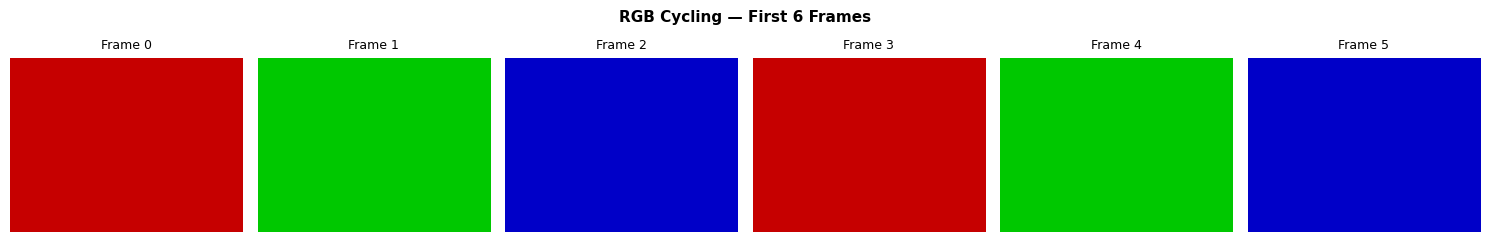

In [4]:
import matplotlib.pyplot as plt

def show_frames(reader, indices, title="Frames", figsize=None):
    """Display a row of frames from a VideoReader."""
    n = len(indices)
    if figsize is None:
        figsize = (2.5 * n, 2.5)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        frame = reader[idx]
        if hasattr(frame, 'numpy'):
            frame = frame.numpy()
        ax.imshow(frame)
        ax.set_title(f"Frame {idx}", fontsize=9)
        ax.axis("off")
    fig.suptitle(title, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Show the R → G → B cycle across the first 6 frames
from frameforge import VideoReader

preview = VideoReader(episode_path, backend="pyav")
print(f"Video: {len(preview)} frames, {preview.fps:.0f} fps, "
      f"{preview.metadata['width']}x{preview.metadata['height']}, "
      f"{preview.duration_sec:.1f}s")
show_frames(preview, [0, 1, 2, 3, 4, 5], title="RGB Cycling — First 6 Frames")
preview.close()

---
## 2. VideoReader — The Core Abstraction

`VideoReader` is the main entry point. It wraps any backend behind a consistent interface with Pythonic indexing.

**Key design decisions:**
- **Auto backend selection** — tries torchcodec → decord → pyav → opencv, picks the first available
- **Lazy initialization** — the backend isn't opened until you actually read a frame, making it safe to pickle and send to DataLoader workers
- **Consistent output** — always returns `(H, W, C)` uint8 tensors (or numpy arrays if you prefer)

In [5]:
from frameforge import VideoReader

# Open with auto backend selection (will pick pyav since we have it installed)
reader = VideoReader(episode_path)

print(f"Backend:    auto (resolved at first access)")
print(f"Path:       {reader._path}")
print(f"Num frames: {len(reader)}")
print(f"FPS:        {reader.fps}")
print(f"Duration:   {reader.duration_sec:.2f}s")
print(f"\nFull metadata:")
for k, v in reader.metadata.items():
    print(f"  {k}: {v}")

2026-04-07 00:36:16.599 | INFO     | frameforge.reader:_auto_select_backend:54 - Auto-selected backend: pyav
2026-04-07 00:36:16.600 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)


Backend:    auto (resolved at first access)
Path:       _videos/test_episode.mp4
Num frames: 2700
FPS:        30.0
Duration:   90.00s

Full metadata:
  fps: 30.0
  num_frames: 2700
  duration_sec: 90.0
  width: 640
  height: 480
  codec: h264


### 2.1 Indexing — single frames, slices, and fancy indexing

`VideoReader` supports three indexing styles, just like numpy arrays:

In [6]:
import torch

# --- Single frame ---
frame = reader[0]
print(f"Single frame:  type={type(frame).__name__}, shape={tuple(frame.shape)}, dtype={frame.dtype}")

# --- Slice (contiguous clip) ---
clip = reader[10:26]  # 16 frames
print(f"Slice [10:26]: type={type(clip).__name__}, shape={tuple(clip.shape)}, dtype={clip.dtype}")

# --- Fancy indexing (pick frames spread across the video) ---
total = len(reader)
pick = [0, total // 4, total // 2, total - 1]
selected = reader[pick]
print(f"Fancy {pick}: shape={tuple(selected.shape)}")

# --- Negative indexing ---
last_frame = reader[-1]
print(f"Last frame reader[-1]: shape={tuple(last_frame.shape)}")

# Verify frame content: frame 0 should be red (channel 0), frame 1 green, frame 2 blue
for i, color in enumerate(["Red", "Green", "Blue"]):
    f = reader[i]
    dominant = f[0, 0].argmax().item()  # which channel is brightest at pixel (0,0)
    print(f"  Frame {i}: dominant channel = {dominant} ({color}{'  ✓' if dominant == i else '  ✗'})")

Single frame:  type=Tensor, shape=(480, 640, 3), dtype=torch.uint8
Slice [10:26]: type=Tensor, shape=(16, 480, 640, 3), dtype=torch.uint8
Fancy [0, 675, 1350, 2699]: shape=(4, 480, 640, 3)
Last frame reader[-1]: shape=(480, 640, 3)
  Frame 0: dominant channel = 0 (Red  ✓)
  Frame 1: dominant channel = 1 (Green  ✓)
  Frame 2: dominant channel = 2 (Blue  ✓)


### 2.2 Numpy output mode

By default, `VideoReader` returns PyTorch tensors. Pass `output="numpy"` for raw numpy arrays:

In [7]:
reader_np = VideoReader(episode_path, output="numpy")
frame_np = reader_np[0]
print(f"Numpy mode: type={type(frame_np).__name__}, shape={frame_np.shape}, dtype={frame_np.dtype}")
reader_np.close()

2026-04-07 00:36:21.460 | INFO     | frameforge.reader:_auto_select_backend:54 - Auto-selected backend: pyav
2026-04-07 00:36:21.462 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)


Numpy mode: type=ndarray, shape=(480, 640, 3), dtype=uint8


### 2.3 Context manager and resource cleanup

`VideoReader` supports `with` blocks. The backend is released on exit — important when dealing with hundreds of videos:

In [8]:
with VideoReader(episode_path) as r:
    clip = r[0:8]
    print(f"Inside context: {len(r)} frames, got clip {tuple(clip.shape)}")

# After exiting, the backend is closed
print(f"After context:  backend is {'closed' if r._backend is None else 'still open'}")

2026-04-07 00:36:22.624 | INFO     | frameforge.reader:_auto_select_backend:54 - Auto-selected backend: pyav
2026-04-07 00:36:22.625 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)


Inside context: 2700 frames, got clip (8, 480, 640, 3)
After context:  backend is closed


---
## 3. Backends — Swap with One Argument

frameforge supports four backends: **PyAV**, **torchcodec**, **decord**, and **OpenCV**. Each has different tradeoffs (see the [backend comparison](../docs/index.html#backends)).

You only need to change the `backend=` argument. The output tensor format stays identical.

| Backend | GPU | Seeking | Install |
|---------|-----|---------|---------|
| `pyav` | No | Accurate | `frameforge[pyav]` |
| `torchcodec` | NVDEC | Accurate | `frameforge[torchcodec]` |
| `decord` | NVDEC | Good | `frameforge[decord]` |
| `opencv` | No | Approximate | `frameforge[opencv]` |

In [9]:
from frameforge.backends.base import BackendNotAvailable

# Try each backend and show which ones are available
backends_to_try = ["pyav", "torchcodec", "decord", "opencv"]

for name in backends_to_try:
    try:
        with VideoReader(episode_path, backend=name) as r:
            frame = r[0]
            print(f"  {name:12s}  ✓  available   frame shape={tuple(frame.shape)}")
    except BackendNotAvailable:
        print(f"  {name:12s}  ✗  not installed")
    except Exception as e:
        print(f"  {name:12s}  ✗  error: {e}")

2026-04-07 00:36:24.436 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)
objc[7555]: Class AVFFrameReceiver is implemented in both /Users/agog13/developer/frameforge/.venv/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x10a07c3a8) and /Users/agog13/developer/frameforge/.venv/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x11d8dc3a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[7555]: Class AVFAudioReceiver is implemented in both /Users/agog13/developer/frameforge/.venv/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x10a07c3f8) and /Users/agog13/developer/frameforge/.venv/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x11d8dc3f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
2026-04-07 00:36:24.496

  pyav          ✓  available   frame shape=(480, 640, 3)
  torchcodec    ✗  not installed
  decord        ✗  not installed
  opencv        ✓  available   frame shape=(480, 640, 3)


---
## 4. Temporal Clip Sampling

Video understanding models don't consume full videos. They need specific **sampling strategies** to select which frames to read.

frameforge provides four samplers — each returns a `(T, H, W, C)` tensor:

| Sampler | Strategy | Typical use |
|---------|----------|-------------|
| `UniformSampler` | Evenly spaced across full video | Evaluation, inference |
| `RandomSampler` | Random window + random frames | Training augmentation |
| `DenseSampler` | Every Nth frame | Action detection |
| `EpisodeSampler` | Uniform within episode boundaries | Robotics manipulation |

In [10]:
from frameforge.sampling import UniformSampler, RandomSampler, DenseSampler, EpisodeSampler

total = len(reader)
vid_fps = reader.fps

# --- Uniform: 8 evenly spaced frames ---
uniform = UniformSampler(num_frames=8)
indices = uniform.get_indices(total_frames=total)
print(f"UniformSampler(8) indices:  {indices}")

clip = uniform.sample(reader)
print(f"  → clip shape: {tuple(clip.shape)}")

# --- Random: 8 frames from a random 1-second window ---
random_s = RandomSampler(num_frames=8, clip_duration_sec=1.0)
indices = random_s.get_indices(total_frames=total, fps=vid_fps)
print(f"\nRandomSampler(8, 1.0s) indices: {indices}")

clip = random_s.sample(reader)
print(f"  → clip shape: {tuple(clip.shape)}")

# --- Dense: every 10th frame ---
dense = DenseSampler(stride=10)
indices = dense.get_indices(total_frames=total)
print(f"\nDenseSampler(stride=10) indices: {indices[:15]}{'...' if len(indices) > 15 else ''}")
print(f"  → {len(indices)} frames total")

# --- Episode-aware: divide video into 3 equal episodes ---
ep_len = total // 3
episode_boundaries = [0, ep_len, ep_len * 2]
episode = EpisodeSampler(episode_boundaries=episode_boundaries, num_frames=8)

print(f"\nEpisodeSampler (boundaries={episode_boundaries}, 8 frames):")
for trial in range(5):
    indices = episode.get_indices(total_frames=total)
    ep_idx = 0 if indices[0] < ep_len else (1 if indices[0] < ep_len * 2 else 2)
    print(f"  trial {trial}: ep{ep_idx} → {indices}")

UniformSampler(8) indices:  [0, 386, 771, 1157, 1542, 1928, 2313, 2699]
  → clip shape: (8, 480, 640, 3)

RandomSampler(8, 1.0s) indices: [217, 220, 221, 222, 226, 240, 241, 244]
  → clip shape: (8, 480, 640, 3)

DenseSampler(stride=10) indices: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140]...
  → 270 frames total

EpisodeSampler (boundaries=[0, 900, 1800], 8 frames):
  trial 0: ep0 → [0, 128, 257, 385, 514, 642, 771, 899]
  trial 1: ep0 → [0, 128, 257, 385, 514, 642, 771, 899]
  trial 2: ep0 → [0, 128, 257, 385, 514, 642, 771, 899]
  trial 3: ep0 → [0, 128, 257, 385, 514, 642, 771, 899]
  trial 4: ep1 → [900, 1028, 1157, 1285, 1414, 1542, 1671, 1799]


### Visualize sampled frames

Let's see what each sampler actually picks. Notice how **Uniform** spreads evenly, **Random** clusters in a window, and **Episode** stays within one segment:

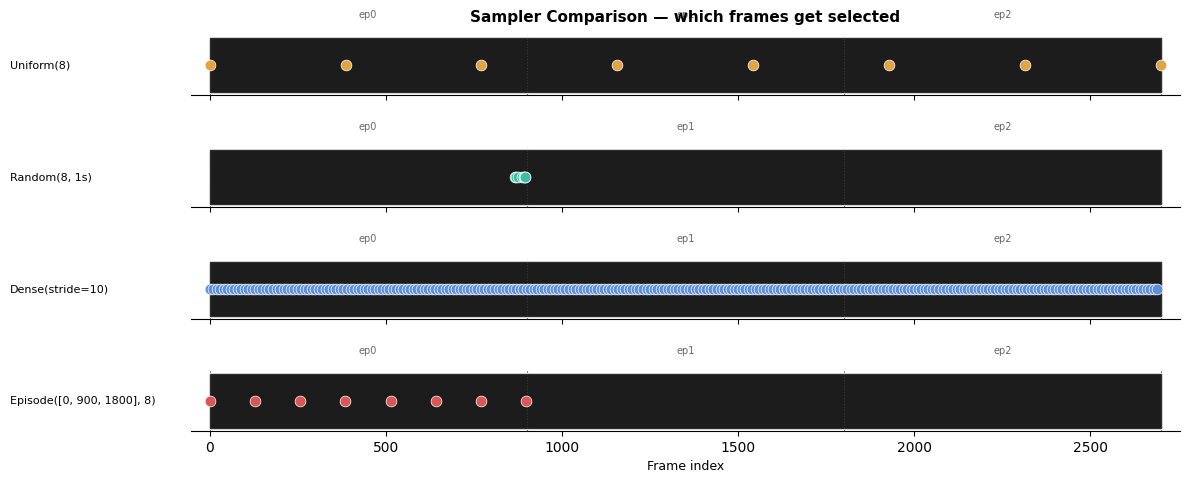

In [11]:
# Visualize what each sampler selects on a timeline
fig, axes = plt.subplots(4, 1, figsize=(12, 5), sharex=True)

samplers_vis = [
    ("Uniform(8)", uniform.get_indices(total), "#e2a442"),
    ("Random(8, 1s)", random_s.get_indices(total, fps=vid_fps), "#3dbea0"),
    ("Dense(stride=10)", dense.get_indices(total), "#5b8fd9"),
    (f"Episode({episode_boundaries}, 8)", episode.get_indices(total), "#d95757"),
]

for ax, (name, idxs, color) in zip(axes, samplers_vis):
    ax.barh(0, total, height=0.4, color="#1c1c1c", edgecolor="#2a2a2a")
    # Draw episode boundaries
    for b in episode_boundaries + [total]:
        ax.axvline(b, color="#3a3a3a", linestyle=":", linewidth=0.8)
    ax.scatter(idxs, [0]*len(idxs), color=color, s=60, zorder=5, edgecolors="white", linewidths=0.5)
    ax.set_yticks([])
    ax.set_ylabel(name, fontsize=8, rotation=0, labelpad=130, ha="left", va="center")
    ax.set_xlim(-total * 0.02, total * 1.02)
    ax.spines[["top", "right", "left"]].set_visible(False)

axes[-1].set_xlabel("Frame index", fontsize=9)
axes[0].set_title("Sampler Comparison — which frames get selected", fontsize=11, fontweight="bold", pad=10)

# Episode labels
for ax in axes:
    for ep_i, (start, end) in enumerate(zip(episode_boundaries, episode_boundaries[1:] + [total])):
        mid = (start + end) / 2
        ax.text(mid, 0.35, f"ep{ep_i}", ha="center", fontsize=7, color="#666")

plt.tight_layout()
plt.show()

### Why episode-aware sampling matters

In robotics datasets, a single video file often contains **multiple task demonstrations** (episodes) back-to-back. A naive `UniformSampler` or `RandomSampler` might sample frames that span two different episodes — mixing "pick up the cup" frames with "place the cup" frames in a single training clip.

`EpisodeSampler` ensures all frames in a clip come from the **same episode**, preserving temporal coherence within a task demonstration.

---
## 5. Multi-Camera Synchronization

Robotics manipulation rigs often have 2-4 cameras (wrist, overhead, third-person). You need time-aligned frames across all views.

`sync_readers_by_timestamp` takes a dict of readers and a list of target timestamps, and returns synchronized frame tensors for each camera.

In [12]:
from frameforge.sampling.sync import sync_readers_by_timestamp

# Open two "cameras"
readers = {
    "wrist": VideoReader(wrist_path, backend="pyav"),
    "overhead": VideoReader(overhead_path, backend="pyav"),
}

# Get synchronized frames at 5 timestamps (0.0s through 2.0s)
timestamps = [0.0, 0.5, 1.0, 1.5, 2.0]
synced = sync_readers_by_timestamp(readers, timestamps)

for cam_name, frames in synced.items():
    print(f"  {cam_name:10s} → {tuple(frames.shape)}, mean pixel value: {frames.float().mean():.1f}")

# Clean up
for r in readers.values():
    r.close()

print(f"\nAll cameras returned {len(timestamps)} synchronized frames each.")

2026-04-07 00:36:33.769 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/cam_wrist.mp4 (2700 frames)
2026-04-07 00:36:33.785 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/cam_overhead.mp4 (2700 frames)


  wrist      → (5, 480, 640, 3), mean pixel value: 59.3
  overhead   → (5, 480, 640, 3), mean pixel value: 39.7

All cameras returned 5 synchronized frames each.


2026-04-07 00:36:34.228 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/cam_wrist.mp4 (2700 frames)
2026-04-07 00:36:34.246 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/cam_overhead.mp4 (2700 frames)


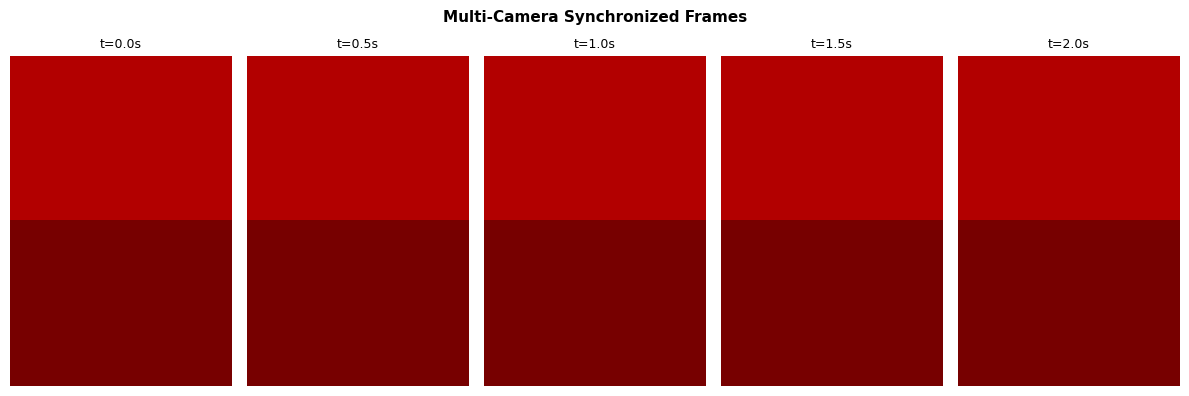

In [13]:
# Visualize synchronized frames across cameras
# Re-open for visualization
readers_vis = {
    "wrist": VideoReader(wrist_path, backend="pyav"),
    "overhead": VideoReader(overhead_path, backend="pyav"),
}
synced_vis = sync_readers_by_timestamp(readers_vis, [0.0, 0.5, 1.0, 1.5, 2.0])

fig, axes = plt.subplots(2, 5, figsize=(12, 4))
for row, (cam, frames) in enumerate(synced_vis.items()):
    for col in range(5):
        frame = frames[col].numpy()
        axes[row, col].imshow(frame)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"t={timestamps[col]}s", fontsize=9)
    axes[row, 0].set_ylabel(cam, fontsize=10, rotation=0, labelpad=60, ha="right", va="center")

fig.suptitle("Multi-Camera Synchronized Frames", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

for r in readers_vis.values():
    r.close()

---
## 6. PyTorch DataLoader Integration

frameforge provides two dataset classes that are **worker-safe by design**:

- **`VideoClipDataset`** (map-style) — one video per index, sampler picks the clip
- **`VideoStreamDataset`** (iterable) — yields sequential clips from a single video

The key safety feature: `VideoReader` is opened inside `__getitem__` (not `__init__`), so file handles are never shared across forked workers.

### Custom collation

Since clips can have different lengths (e.g., short episodes), frameforge provides:
- `video_collate` — pads to max length, returns `(B, T_max, H, W, C)`
- `video_collate_with_mask` — same but also returns a `(B, T_max)` boolean mask

In [14]:
from torch.utils.data import DataLoader
from frameforge.dataloader import VideoClipDataset, VideoStreamDataset
from frameforge.dataloader.collate import video_collate, video_collate_with_mask

# === Map-style dataset ===
# Imagine we have 3 episode videos (we'll reuse our test video 3 times)
video_paths = [episode_path, wrist_path, overhead_path]

dataset = VideoClipDataset(
    video_paths=video_paths,
    sampler=UniformSampler(num_frames=8),
    backend="pyav",
    transform=lambda x: x.float() / 255.0,  # normalize to [0, 1]
)

print(f"VideoClipDataset: {len(dataset)} videos")
print(f"  dataset[0] shape: {tuple(dataset[0].shape)}, dtype: {dataset[0].dtype}")

# Use with DataLoader (num_workers=0 for notebook compatibility)
loader = DataLoader(dataset, batch_size=2, num_workers=0, collate_fn=video_collate)

for batch_idx, batch in enumerate(loader):
    print(f"\n  Batch {batch_idx}: shape={tuple(batch.shape)}, dtype={batch.dtype}")
    print(f"    min={batch.min():.3f}, max={batch.max():.3f}")

print("\n--- Collation with mask (for variable-length clips) ---")
# Demonstrate the mask collation
t1 = torch.zeros(8, 64, 64, 3, dtype=torch.uint8)
t2 = torch.zeros(12, 64, 64, 3, dtype=torch.uint8)
padded, mask = video_collate_with_mask([t1, t2])
print(f"  Padded: {tuple(padded.shape)}")
print(f"  Mask:   {tuple(mask.shape)}")
print(f"  Clip 0 valid frames: {mask[0].sum().item()}/12")
print(f"  Clip 1 valid frames: {mask[1].sum().item()}/12")

2026-04-07 00:36:38.170 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)
2026-04-07 00:36:38.199 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)
2026-04-07 00:36:38.217 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)
2026-04-07 00:36:38.232 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/cam_wrist.mp4 (2700 frames)
2026-04-07 00:36:38.254 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/cam_overhead.mp4 (2700 frames)


VideoClipDataset: 3 videos
  dataset[0] shape: (8, 480, 640, 3), dtype: torch.float32

  Batch 0: shape=(2, 8, 480, 640, 3), dtype=torch.float32
    min=0.000, max=0.784

  Batch 1: shape=(1, 8, 480, 640, 3), dtype=torch.float32
    min=0.000, max=0.467

--- Collation with mask (for variable-length clips) ---
  Padded: (2, 12, 64, 64, 3)
  Mask:   (2, 12)
  Clip 0 valid frames: 8/12
  Clip 1 valid frames: 12/12


### Streaming dataset

`VideoStreamDataset` yields non-overlapping sequential clips from a single video. Useful for processing long recordings end-to-end:

In [15]:
stream_ds = VideoStreamDataset(
    video_path=episode_path,
    sampler=UniformSampler(8),
    backend="pyav",
    clip_length=16,
)

clips = list(stream_ds)
print(f"VideoStreamDataset yielded {len(clips)} clips of 16 frames each")
print(f"  Total frames covered: {len(clips) * 16} / {total}")

2026-04-07 00:36:39.365 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)
2026-04-07 00:36:39.618 | WARNING  | frameforge.backends.pyav_backend:read_clip:103 - Expected 16 frames but decoded 17 for clip [480, 496)
2026-04-07 00:36:39.625 | WARNING  | frameforge.backends.pyav_backend:read_clip:103 - Expected 16 frames but decoded 15 for clip [496, 512)
2026-04-07 00:36:39.849 | WARNING  | frameforge.backends.pyav_backend:read_clip:103 - Expected 16 frames but decoded 17 for clip [976, 992)
2026-04-07 00:36:39.857 | WARNING  | frameforge.backends.pyav_backend:read_clip:103 - Expected 16 frames but decoded 15 for clip [992, 1008)
2026-04-07 00:36:40.214 | WARNING  | frameforge.backends.pyav_backend:read_clip:103 - Expected 16 frames but decoded 17 for clip [1760, 1776)
2026-04-07 00:36:40.221 | WARNING  | frameforge.backends.pyav_backend:read_clip:103 - Expected 16 frames but decoded 15 for clip [1776, 1792)
2026-04-07 00:36:40.305 

VideoStreamDataset yielded 168 clips of 16 frames each
  Total frames covered: 2688 / 2700


---
## 7. Pickling & Worker Safety

The #1 bug in video ML pipelines: opening a video file in the main process, then forking workers that inherit corrupted file handles.

frameforge's `VideoReader` handles this by:
1. **Lazy init** — backend isn't opened until first frame access
2. **Pickle drops the backend** — after unpickling in a worker, the reader re-opens the file fresh

In [16]:
import pickle

# Open a reader and force backend initialization
reader_orig = VideoReader(episode_path, backend="pyav")
_ = reader_orig[0]  # triggers lazy init
print(f"Before pickle: backend is {'open' if reader_orig._backend else 'None'}")

# Pickle and unpickle (simulates what DataLoader does when sending to workers)
data = pickle.dumps(reader_orig)
reader_copy = pickle.loads(data)
print(f"After pickle:  backend is {'open' if reader_copy._backend else 'None'}")

# The unpickled reader works fine — it re-opens on first access
frame = reader_copy[0]
print(f"After access:  backend is {'open' if reader_copy._backend else 'None'}")
print(f"  frame shape: {tuple(frame.shape)}")

reader_orig.close()
reader_copy.close()

2026-04-07 00:36:43.594 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)
2026-04-07 00:36:43.602 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)


Before pickle: backend is open
After pickle:  backend is None
After access:  backend is open
  frame shape: (480, 640, 3)


---
## 8. Benchmarking

frameforge includes a benchmark suite to compare backends on your hardware. It measures:
- **Decode throughput** (frames/sec)
- **Latency percentiles** (p50, p95, p99)
- **Peak memory usage**

You can run from CLI (`python -m frameforge.benchmark run`) or programmatically:

In [17]:
from frameforge.benchmark import BenchmarkConfig, run_benchmark

config = BenchmarkConfig(
    backend="pyav",
    video_path=episode_path,
    num_trials=30,           # keep small for notebook
    clip_length_frames=16,
    seek_mode="sequential",
)

print(f"Running benchmark: {config.backend}, {config.num_trials} trials, "
      f"{config.clip_length_frames} frames/clip, {config.seek_mode} seek...")

result = run_benchmark(config)

print(f"\n{'='*50}")
print(f"  Backend:           {result.backend}")
print(f"  Throughput:        {result.decode_throughput_fps:.1f} fps")
print(f"  Latency p50:       {result.latency_p50_ms:.1f} ms")
print(f"  Latency p95:       {result.latency_p95_ms:.1f} ms")
print(f"  Latency p99:       {result.latency_p99_ms:.1f} ms")
print(f"  Peak memory:       {result.memory_peak_mb:.1f} MB")
print(f"  System:            {result.system_info.get('platform', 'unknown')}")
print(f"{'='*50}")

2026-04-07 00:36:47.594 | INFO     | frameforge.benchmark.runner:run_benchmark:91 - Benchmarking backend=pyav video=_videos/test_episode.mp4 trials=30 clip_len=16 seek=sequential
2026-04-07 00:36:47.595 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)


Running benchmark: pyav, 30 trials, 16 frames/clip, sequential seek...


2026-04-07 00:36:47.842 | WARNING  | frameforge.backends.pyav_backend:read_clip:103 - Expected 16 frames but decoded 17 for clip [480, 496)
2026-04-07 00:36:47.850 | WARNING  | frameforge.backends.pyav_backend:read_clip:103 - Expected 16 frames but decoded 15 for clip [496, 512)



  Backend:           pyav
  Throughput:        2128.0 fps
  Latency p50:       7.4 ms
  Latency p95:       8.2 ms
  Latency p99:       8.9 ms
  Peak memory:       29.1 MB
  System:            macOS-26.3.2-arm64-arm-64bit


### Serialize results to JSON

Results are dataclasses with built-in JSON serialization — useful for CI pipelines or building comparison dashboards:

In [18]:
import json

# Serialize
json_str = result.to_json()
print("JSON output (first 300 chars):")
print(json_str[:300] + "...")

# Deserialize
from frameforge.benchmark.runner import BenchmarkResult
result_back = BenchmarkResult.from_json(json_str)
print(f"\nRound-trip: throughput={result_back.decode_throughput_fps:.1f} fps ✓")

JSON output (first 300 chars):
{
  "backend": "pyav",
  "video_path": "_videos/test_episode.mp4",
  "num_trials": 30,
  "clip_length_frames": 16,
  "seek_mode": "sequential",
  "decode_throughput_fps": 2128.0184135018267,
  "latency_p50_ms": 7.387791501969332,
  "latency_p95_ms": 8.152273099403828,
  "latency_p99_ms": 8.870583790...

Round-trip: throughput=2128.0 fps ✓


---
## 9. Performance: Frame Index Cache & Decode Prefetch

frameforge has two opt-in acceleration features:

| Feature | What it does | Speedup | Best for |
|---------|-------------|---------|----------|
| **`cache_index=True`** | Scans keyframes once, caches index to disk. Knows exactly how many frames must be decoded for any seek. | 2-3x random access | Random reads, large-GOP videos |
| **`prefetch=True`** | Background thread with its own decoder reads ahead, filling an LRU cache. | 2-4x sequential | DataLoader workloads, clip reads |

Both are just flags on `VideoReader` — no API changes.

### 9.1 Frame Index Cache

The index scans every packet header (not pixel data) to map each frame to its nearest keyframe.
It caches to `.frameforge_cache/` next to the video — subsequent opens load instantly.

In [19]:
from frameforge.cache import VideoFrameIndex

# Build (or load from cache) a frame index
index = VideoFrameIndex.build_or_load(episode_path)

print(f"Video:       {episode_path.name}")
print(f"Frames:      {index.num_frames}")
print(f"Keyframes:   {index.num_keyframes}")
print(f"Avg GOP:     {index.avg_gop_size:.1f} frames")
print()

# How expensive is it to seek to specific frames?
sample_indices = [0, 10, index.num_frames // 2, index.num_frames - 1]
for idx in sample_indices:
    n_dec = index.frames_to_decode(idx)
    kf = 'KEYFRAME' if index.is_keyframe(idx) else f'decode {n_dec} from keyframe'
    print(f"  Frame {idx:5d}: {kf}")

2026-04-07 00:36:54.499 | INFO     | frameforge.cache:build:110 - Building frame index for test_episode.mp4 ...
2026-04-07 00:36:54.507 | INFO     | frameforge.cache:build:149 - Index built: 2700 frames, 100 keyframes, avg GOP 27.0
2026-04-07 00:36:54.509 | DEBUG    | frameforge.cache:save:184 - Frame index saved to _videos/.frameforge_cache/test_episode_20e49227d1e2493e.fidx (44.8 KB)


Video:       test_episode.mp4
Frames:      2700
Keyframes:   100
Avg GOP:     27.0 frames

  Frame     0: KEYFRAME
  Frame    10: decode 11 from keyframe
  Frame  1350: decode 2 from keyframe
  Frame  2699: decode 28 from keyframe


### 9.2 Performance Comparison

Let's measure the actual speedup from `cache_index` and `prefetch` on random and sequential access patterns.

In [20]:
import time
import random

total_frames = len(VideoReader(episode_path))
print(f'Benchmarking on {episode_path.name} ({total_frames} frames)')
print(f'{"="*60}')

# --- Test 1: Random single-frame reads (cache_index helps) ---
random.seed(42)
indices = [random.randint(0, total_frames - 1) for _ in range(30)]

r = VideoReader(episode_path, backend='pyav')
_ = r[0]
t0 = time.perf_counter()
for idx in indices: _ = r[idx]
t_base_rand = time.perf_counter() - t0
r.close()

r = VideoReader(episode_path, backend='pyav', cache_index=True)
_ = r[0]
t0 = time.perf_counter()
for idx in indices: _ = r[idx]
t_cache_rand = time.perf_counter() - t0
r.close()

print(f'  Random frames (30 reads):')
print(f'    baseline:     {t_base_rand*1000:7.1f} ms')
print(f'    cache_index:  {t_cache_rand*1000:7.1f} ms  ({t_base_rand/t_cache_rand:.2f}x)')

# --- Test 2: Sequential reads (prefetch cache-hit demo) ---
# Prefetch: read frame 0, let background thread decode ahead,
# then read frames 1-16 — they should already be cached
r = VideoReader(episode_path, backend='pyav', prefetch=True, prefetch_ahead=32)
_ = r[0]  # triggers prefetch of frames 1-32
time.sleep(0.8)  # give prefetch thread time to fill cache
stats = r.prefetch_stats
t0 = time.perf_counter()
for i in range(1, 17): _ = r[i]
t_hit = time.perf_counter() - t0
r.close()

r = VideoReader(episode_path, backend='pyav')
_ = r[0]
t0 = time.perf_counter()
for i in range(1, 17): _ = r[i]
t_nohit = time.perf_counter() - t0
r.close()

print(f'\n  Sequential frames 1-16 (prefetch cache-hit):')
print(f'    baseline:     {t_nohit*1000:7.1f} ms')
print(f'    prefetch:     {t_hit*1000:7.1f} ms  ({t_nohit/t_hit:.2f}x)')
print(f'    (prefetch had {stats["cached_frames"]} frames ready in cache)')


2026-04-07 00:36:59.419 | INFO     | frameforge.reader:_auto_select_backend:54 - Auto-selected backend: pyav
2026-04-07 00:36:59.421 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)
2026-04-07 00:36:59.423 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)
2026-04-07 00:36:59.481 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)
2026-04-07 00:36:59.482 | DEBUG    | frameforge.cache:load:210 - Frame index loaded from cache: 2700 frames
2026-04-07 00:36:59.482 | DEBUG    | frameforge.reader:_init_frame_index:137 - Frame index ready: 2700 frames, 100 keyframes, avg GOP 27.0
2026-04-07 00:36:59.523 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)
2026-04-07 00:36:59.524 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (27

Benchmarking on test_episode.mp4 (2700 frames)
  Random frames (30 reads):
    baseline:        53.3 ms
    cache_index:     38.5 ms  (1.38x)


2026-04-07 00:37:00.333 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)



  Sequential frames 1-16 (prefetch cache-hit):
    baseline:        31.6 ms
    prefetch:         0.6 ms  (56.83x)
    (prefetch had 33 frames ready in cache)


### 9.3 Visualize the Results

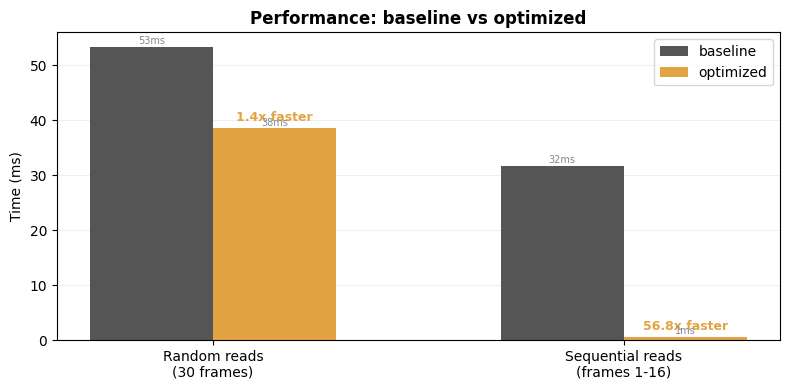

In [21]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Random reads\n(30 frames)', 'Sequential reads\n(frames 1-16)']
baseline_ms = [t_base_rand*1000, t_nohit*1000]
optimized_ms = [t_cache_rand*1000, t_hit*1000]
opt_names = ['cache_index', 'prefetch']

x = np.arange(len(categories))
w = 0.3

fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - w/2, baseline_ms, w, label='baseline', color='#555555')
bars2 = ax.bar(x + w/2, optimized_ms, w, label='optimized', color='#e2a442')

for i in range(len(categories)):
    if optimized_ms[i] > 0:
        sp = baseline_ms[i] / optimized_ms[i]
        ax.annotate(f'{sp:.1f}x faster', xy=(x[i] + w/2, optimized_ms[i]),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=9, fontweight='bold', color='#e2a442')

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.0f}ms', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 2), textcoords='offset points',
                    ha='center', fontsize=7, color='#888')

ax.set_ylabel('Time (ms)')
ax.set_title('Performance: baseline vs optimized', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### 9.4 Inspect Prefetch Cache at Runtime

You can check the prefetcher's cache stats to see how many frames are cached and how much memory is used:

In [22]:
# Inspect prefetch cache at runtime
r = VideoReader(episode_path, backend='pyav', prefetch=True,
                prefetch_cache_size=64, prefetch_ahead=16)
_ = r[0]          # triggers prefetch of frames 1-16
time.sleep(0.5)   # let background thread work

stats = r.prefetch_stats
print('Prefetch cache stats after reading frame 0 + 0.5s wait:')
for k, v in stats.items():
    print(f'  {k:25s}: {v:.2f}' if isinstance(v, float) else f'  {k:25s}: {v}')

# Frames 1-4 should be instant (cache hits)
t0 = time.perf_counter()
for i in range(1, 5): _ = r[i]
print(f'\nFrames 1-4 (prefetched):  {(time.perf_counter()-t0)*1000:.1f} ms')

r.close()


2026-04-07 00:37:35.200 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)
2026-04-07 00:37:35.201 | DEBUG    | frameforge.backends.pyav_backend:open:49 - PyAV opened _videos/test_episode.mp4 (2700 frames)
2026-04-07 00:37:35.202 | DEBUG    | frameforge.prefetch:start:81 - Prefetcher started: cache_size=64, ahead=16, backend=pyav


Prefetch cache stats after reading frame 0 + 0.5s wait:
  cached_frames            : 17
  cache_size_limit         : 64
  prefetch_ahead           : 16
  cache_memory_mb          : 14.94

Frames 1-4 (prefetched):  0.3 ms


---
## 10. VideoWriter — Encoding Back to Disk

`VideoWriter` encodes frames or clips to H.264 video files. Useful for saving model predictions, processed episodes, or debug visualizations.

In [ ]:
from frameforge.writer import VideoWriter

# Read a clip, "process" it (invert colors), and write to a new file
with VideoReader(episode_path, backend="pyav") as r:
    clip = r[0:30]  # 30 frames, (T, H, W, C)
    vid_w, vid_h = r.metadata["width"], r.metadata["height"]

# "Process" — invert the colors
processed = 255 - clip
print(f"Original clip:  shape={tuple(clip.shape)}, mean={clip.float().mean():.1f}")
print(f"Processed clip: shape={tuple(processed.shape)}, mean={processed.float().mean():.1f}")

# Write to disk
output_path = VIDEO_DIR / "processed_output.mp4"
with VideoWriter(output_path, fps=30, width=vid_w, height=vid_h) as w:
    w.write_clip(processed)

print(f"\nWritten to {output_path} ({output_path.stat().st_size / 1024:.1f} KB)")

# Verify: read it back
with VideoReader(output_path, backend="pyav") as r:
    print(f"Verification: {len(r)} frames, {r.fps} fps, {r.metadata['codec']}")

In [ ]:
# Visual comparison: original vs processed (inverted)
fig, axes = plt.subplots(2, 6, figsize=(13, 4))

with VideoReader(episode_path, backend="pyav") as orig, \
     VideoReader(output_path, backend="pyav") as proc:
    for col in range(6):
        idx = col * 5
        axes[0, col].imshow(orig[idx].numpy())
        axes[0, col].set_title(f"Frame {idx}", fontsize=8)
        axes[0, col].axis("off")
        
        axes[1, col].imshow(proc[idx].numpy())
        axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10, rotation=0, labelpad=55, ha="right", va="center")
axes[1, 0].set_ylabel("Inverted", fontsize=10, rotation=0, labelpad=55, ha="right", va="center")
fig.suptitle("VideoWriter Round-Trip: Read → Process → Write → Read Back", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 11. Putting It All Together — A Robotics Training Pipeline

Here's what a realistic data pipeline looks like using frameforge. This is the pattern you'd use for training a manipulation policy or video understanding model:

In [ ]:
import torch
from torch.utils.data import DataLoader
from frameforge import VideoReader
from frameforge.dataloader import VideoClipDataset
from frameforge.dataloader.collate import video_collate
from frameforge.sampling import EpisodeSampler

# --- 1. Define your dataset ---
episode_videos = [episode_path, wrist_path, overhead_path]

# Episode boundaries (in a real pipeline, loaded from a metadata file)
# Divide each video into 3 equal episodes
sampler = EpisodeSampler(
    episode_boundaries=episode_boundaries,
    num_frames=16,
)

# --- 2. Create dataset with normalization transform ---
def preprocess(clip: torch.Tensor) -> torch.Tensor:
    """Normalize uint8 clip to float32 [0, 1] and rearrange to (T, C, H, W)."""
    clip = clip.float() / 255.0
    clip = clip.permute(0, 3, 1, 2)  # (T, H, W, C) → (T, C, H, W)
    return clip

dataset = VideoClipDataset(
    video_paths=episode_videos,
    sampler=sampler,
    backend="pyav",
    transform=preprocess,
)

# --- 3. DataLoader ---
loader = DataLoader(
    dataset,
    batch_size=2,
    num_workers=0,      # use >0 in real training
    shuffle=True,
)

# --- 4. Training loop (simulated) ---
print("Simulated training loop:")
for epoch in range(2):
    for batch_idx, batch in enumerate(loader):
        # batch shape: (B, T, C, H, W) after permute
        print(f"  epoch {epoch}, batch {batch_idx}: shape={tuple(batch.shape)}, "
              f"dtype={batch.dtype}, range=[{batch.min():.2f}, {batch.max():.2f}]")

print("\nDone! In a real pipeline, you'd feed these batches to your model.")

---
## Cleanup

In [ ]:
import shutil

reader.close()
shutil.rmtree(VIDEO_DIR, ignore_errors=True)
print("Cleaned up temporary videos.")

---
## What's Next?

- **[Video Formats Guide](../docs/video-compression.html)** — understand H.264, GOP structure, chroma subsampling, and why it matters for your pipeline
- **[Benchmark Results](../docs/benchmarks.html)** — throughput and latency comparison across backends
- **[Architecture](../docs/architecture.md)** — system design, class hierarchy, and data flow diagrams
- **CLI benchmarking** — run `python -m frameforge.benchmark run --backend pyav --video your_video.mp4`
- **GPU backends** — install `torchcodec` or `decord` with CUDA support on a machine with an NVIDIA GPU